In [16]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

In [17]:
# 1. NẠP DỮ LIỆU
print("📂 Đang nạp dữ liệu...")
df = pd.read_csv("../data/processed_malicious_url.csv").drop_duplicates(subset=['url'])
X = df.drop(columns=['url', 'target'])
y_true = df['target']

# 2. CHUẨN HÓA (Bắt buộc cho K-Means vì nó tính khoảng cách Euclidean)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

📂 Đang nạp dữ liệu...


In [18]:
# 3. TÌM SỐ CỤM TỐI ƯU (ELBOW METHOD)
print("🔍 Đang tính toán tìm số cụm tối ưu (Elbow Method)...")
wcss = []
for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

🔍 Đang tính toán tìm số cụm tối ưu (Elbow Method)...


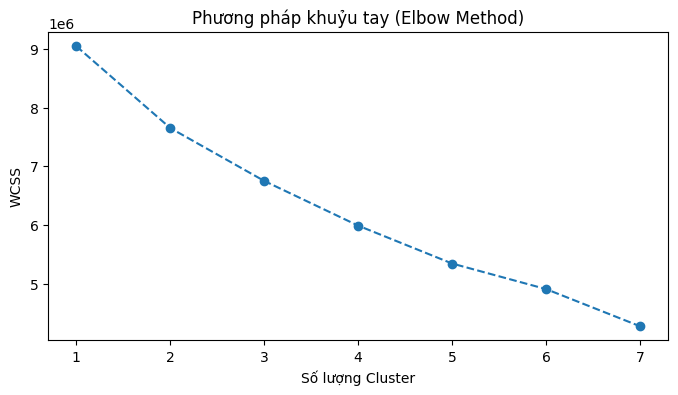

In [19]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 8), wcss, marker='o', linestyle='--')
plt.title('Phương pháp khuỷu tay (Elbow Method)')
plt.xlabel('Số lượng Cluster')
plt.ylabel('WCSS')
plt.show()

In [20]:
# 4. TIẾN HÀNH GOM CỤM VỚI K=4 (Tương ứng 4 nhãn dữ liệu)
print("🚀 Đang gom cụm với K=4...")
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

🚀 Đang gom cụm với K=4...


In [21]:
# 5. PHÂN TÍCH SỰ GIAO THOA (CROSSTAB)
print("\n📊 Bảng so khớp giữa Cluster (Gom cụm) và Target (Nhãn thực tế):")
comparison = pd.crosstab(df['target'], df['cluster'])
print(comparison)


📊 Bảng so khớp giữa Cluster (Gom cụm) và Target (Nhãn thực tế):
cluster          0     1       2      3
target                                 
benign      154160  6624  272254     42
defacement   67139     0   28169      0
malware       7235    38    4602  11770
phishing     21449  1820   70482    333


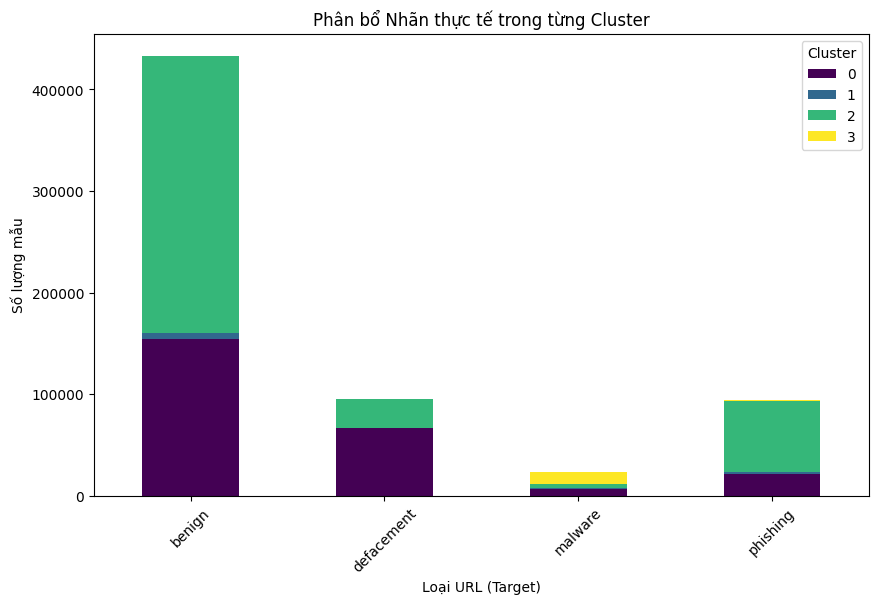

In [22]:
import matplotlib.pyplot as plt

# Vẽ biểu đồ cột chồng (Stacked Bar Chart) từ bảng crosstab
comparison.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Phân bổ Nhãn thực tế trong từng Cluster')
plt.xlabel('Loại URL (Target)')
plt.ylabel('Số lượng mẫu')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.show()

In [23]:
# 6. TRỰC QUAN HÓA BẰNG PCA (Giảm chiều để vẽ biểu đồ 2D)
print("\n🎨 Đang vẽ biểu đồ phân cụm (giảm chiều bằng PCA)...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


🎨 Đang vẽ biểu đồ phân cụm (giảm chiều bằng PCA)...


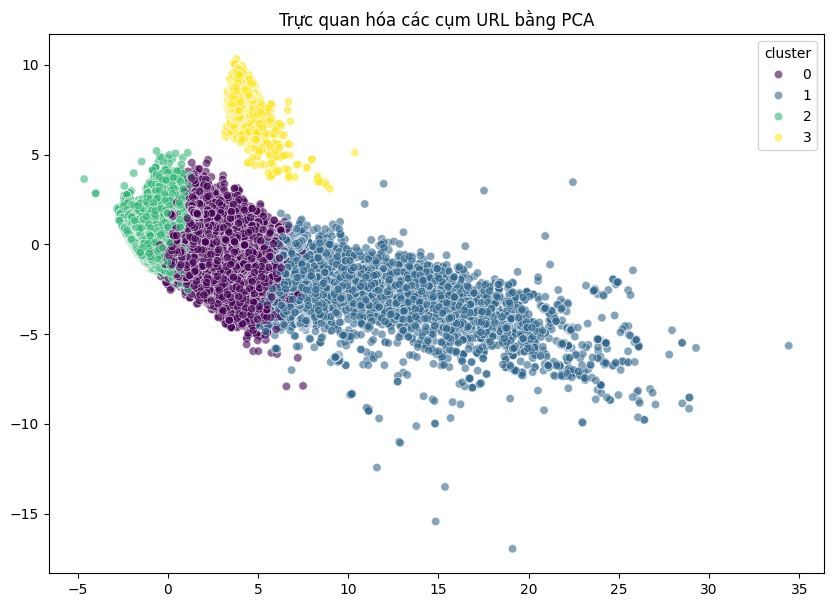

In [24]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='viridis', alpha=0.6)
plt.title('Trực quan hóa các cụm URL bằng PCA')
plt.show()

In [25]:
# 7. LƯU BỘ CHUẨN HÓA VÀ MODEL
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(kmeans, "../models/kmeans_model.pkl")
print("✅ Đã lưu Scaler và K-Means model!")

✅ Đã lưu Scaler và K-Means model!


📈 Đang chuẩn bị dữ liệu và huấn luyện Logistic Regression...
🎯 Accuracy Logistic Regression: 75.20%

📊 BÁO CÁO CHI TIẾT:
              precision    recall  f1-score   support

      benign       0.76      0.95      0.84     86616
  defacement       0.73      0.54      0.62     19062
     malware       0.96      0.77      0.86      4729
    phishing       0.43      0.05      0.10     18817

    accuracy                           0.75    129224
   macro avg       0.72      0.58      0.60    129224
weighted avg       0.71      0.75      0.70    129224



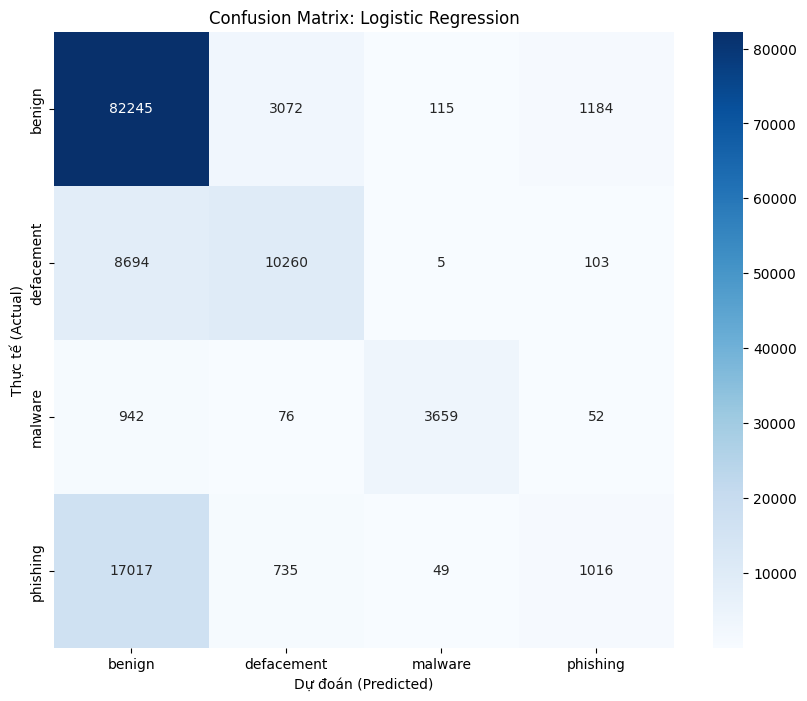

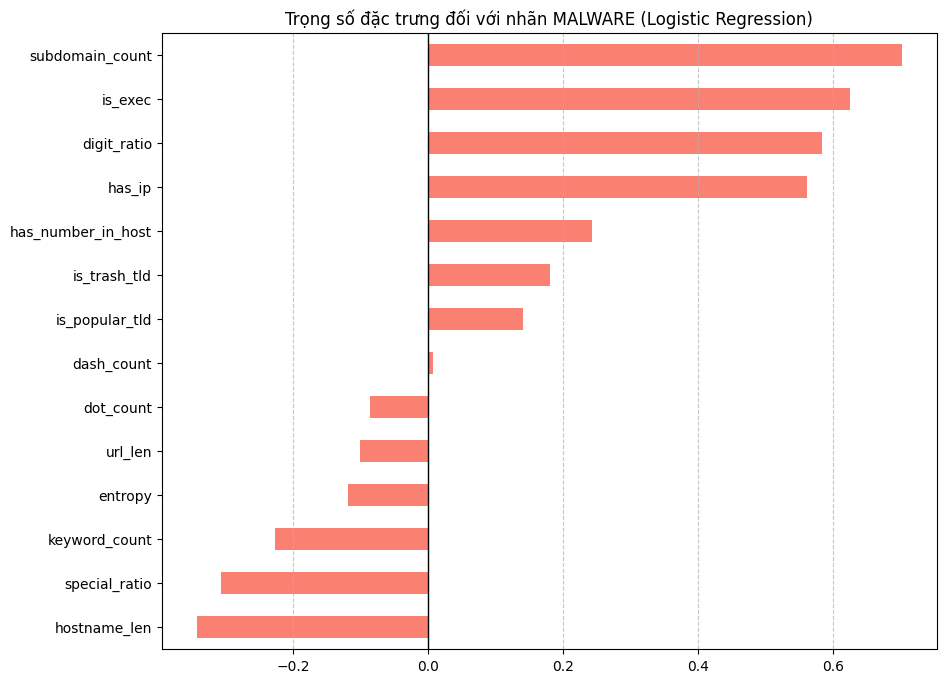

['../models/logistic_baseline.pkl']

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Đảm bảo đã có y (nhãn) từ bước trước, nếu chưa có thì chạy dòng này:
if 'y' not in locals():
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y = le.fit_transform(df['target'])

print("📈 Đang chuẩn bị dữ liệu và huấn luyện Logistic Regression...")

# 1. Chia dữ liệu (Sử dụng X_scaled đã có từ bước Clustering)
# Nếu X_scaled chưa có, hãy đảm bảo ông đã chạy cell StandardScaler phía trên
x_train, x_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# 2. Chuyển sang DataFrame để giữ tên cột cho biểu đồ
feature_cols = X.columns 
x_train_df = pd.DataFrame(x_train, columns=feature_cols)
x_test_df = pd.DataFrame(x_test, columns=feature_cols)

# 3. Khởi tạo và Huấn luyện Logistic Regression
# solver='lbfgs' là chuẩn cho bài toán đa lớp hiện nay
log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
log_reg.fit(x_train_df, y_train)

# 4. Dự đoán
y_pred_log = log_reg.predict(x_test_df)

# 5. Kết quả Accuracy
print(f"🎯 Accuracy Logistic Regression: {accuracy_score(y_test, y_pred_log)*100:.2f}%")
print("\n📊 BÁO CÁO CHI TIẾT:")
print(classification_report(y_test, y_pred_log, target_names=le.classes_))

# 6. VẼ CONFUSION MATRIX
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.show()

# 7. TRÍCH XUẤT TRỌNG SỐ (Feature Coefficients) cho nhãn MALWARE
malware_idx = list(le.classes_).index('malware')
weights = pd.Series(log_reg.coef_[malware_idx], index=x_train_df.columns)

plt.figure(figsize=(10, 8))
weights.sort_values().plot(kind='barh', color='salmon')
plt.title('Trọng số đặc trưng đối với nhãn MALWARE (Logistic Regression)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

joblib.dump(log_reg, "../models/logistic_baseline.pkl")